In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns


In [69]:
df=pd.read_csv(r"d:\Downloads_ML_aaa\Concrete_Data_Yeh.csv")
df.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [71]:
X=df.iloc[:,0:8]
y=df.iloc[:,-1]

In [72]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=23)

Text(0.5, 1.0, 'fineaggregate')

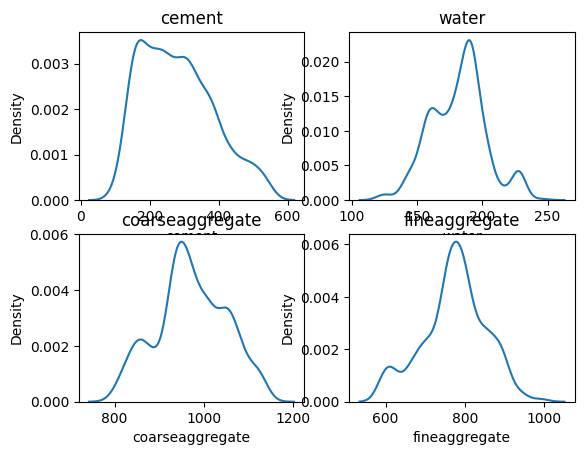

In [73]:
plt.Figure(figsize=(14,4))
plt.subplot(2,2,1)
sns.kdeplot(df,x="cement")
plt.title("cement")

plt.subplot(2,2,2)
sns.kdeplot(df,x="water")
plt.title("water")

plt.subplot(2,2,3)
sns.kdeplot(df,x="coarseaggregate")
plt.title("coarseaggregate")

plt.subplot(2,2,4)
sns.kdeplot(df,x="fineaggregate")
plt.title("fineaggregate")

((array([-3.17567093e+00, -2.90876798e+00, -2.75971342e+00, -2.65453174e+00,
         -2.57243798e+00, -2.50471086e+00, -2.44683196e+00, -2.39614688e+00,
         -2.35095899e+00, -2.31011577e+00, -2.27279737e+00, -2.23839908e+00,
         -2.20646169e+00, -2.17662795e+00, -2.14861431e+00, -2.12219181e+00,
         -2.09717279e+00, -2.07340149e+00, -2.05074713e+00, -2.02909881e+00,
         -2.00836165e+00, -1.98845380e+00, -1.96930418e+00, -1.95085061e+00,
         -1.93303840e+00, -1.91581918e+00, -1.89914994e+00, -1.88299230e+00,
         -1.86731179e+00, -1.85207741e+00, -1.83726112e+00, -1.82283751e+00,
         -1.80878345e+00, -1.79507783e+00, -1.78170134e+00, -1.76863625e+00,
         -1.75586627e+00, -1.74337637e+00, -1.73115265e+00, -1.71918226e+00,
         -1.70745326e+00, -1.69595456e+00, -1.68467582e+00, -1.67360740e+00,
         -1.66274031e+00, -1.65206609e+00, -1.64157686e+00, -1.63126519e+00,
         -1.62112412e+00, -1.61114707e+00, -1.60132787e+00, -1.59166068e+00,

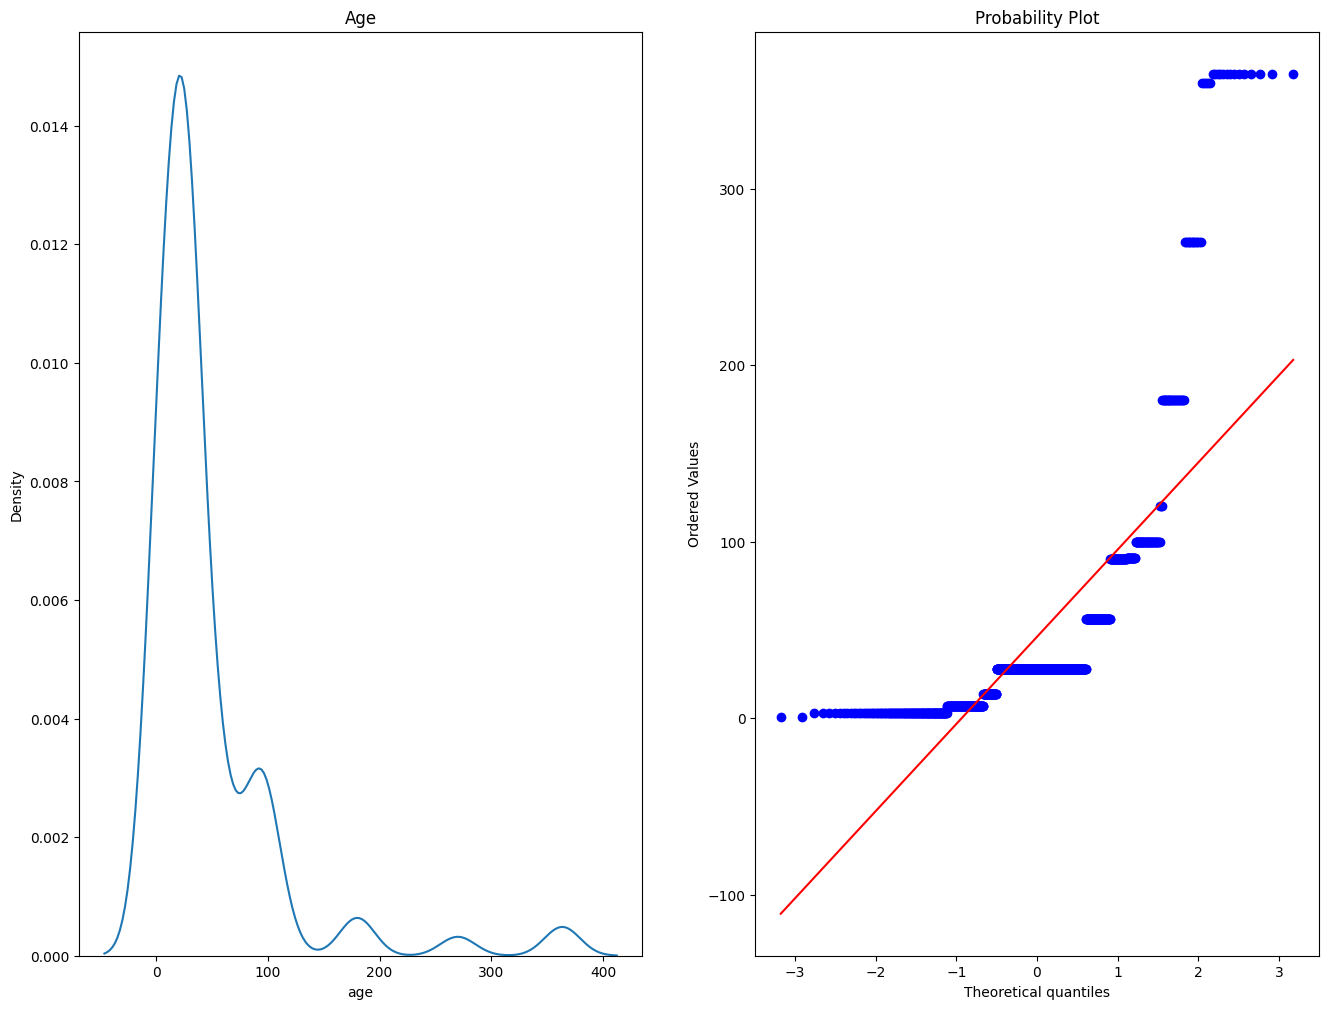

In [74]:
fig,ax=plt.subplots(1,2,figsize=(16,12))
sns.kdeplot(df,x="age",ax=ax[0])
ax[0].set_title("Age")
stats.probplot(X_train["age"],dist="norm",plot=plt)

In [75]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print("R2_score:",r2_score(y_test,y_pred))

R2_score: 0.6811060654565458


In [76]:
# cross checking

np.mean(cross_val_score(model,X,y,scoring="r2",cv=5))

np.float64(0.4609940491662864)

In [79]:
trf=PowerTransformer(method="box-cox")

X_train_transformed=trf.fit_transform(X_train+0.000000000000001)
X_test_transformed=trf.transform(X_test+0.000000000000001)


# pd.DataFrame({"cols":X_train.columns,"box-cox_lambdas":trf.lambdas_})

In [80]:
model2=LinearRegression()
model2.fit(X_train_transformed,y_train)
y_pred2=model2.predict(X_test_transformed)
print("r2_score:",r2_score(y_test,y_pred2))
# np.mean(cross_val_score(X_tr))

r2_score: 0.8024860960133198


In [91]:
np.mean(cross_val_score(model2,X_train_transformed+1e-15,y_train,scoring="r2",cv=10))

np.float64(0.79285571172647)